# HW3

 The dataset for this assignment is the SPAMBASE dataset from the UCI repository available at [here](https://archive.ics.uci.edu/dataset/94/spambase). The first 57 columns are features counting word frequencies (see documentation [here](https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.names)). The last column indicates 1 for the SPAM class and 0 for the HAM class.

In [29]:
import pandas as pd

# import names bc the csv file doesn't have headers
names = ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_;', 'char_freq_(]', 'charFreq_[', 'charFreq_!', 'charFreq_$', 'charFreq_#', 'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total', 'is_spam']


spam_data_pd = pd.read_csv('spambase/spambase.csv', header=None, names=names)

spam_data_pd.head()


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(],charFreq_[,charFreq_!,charFreq_$,charFreq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


# *[C]* Problem 1: Logistic regression (25 points)

Use an existing package of your choice to train and test a logistic regression model on the *SPAMBASE* dataset.

1. Split the original data into 75% for training and 25% for testing. Choose the training set at random. Train a logistic regression model on the training set and output the following **on the testing set**:
    1. **Confusion matrix**
    2. **Accuracy**, **Error**
    3. **Precision**, **Recall**, **F1 score**
2. Print the coefficients of the features in the model. Which features contribute mostly to the prediction? Which ones are positively
correlated and which ones are negatively correlated with the SPAM class?
3. Vary the decision threshold $T \in \{0.25,0.5,0.75,0.9\}$ and report for each value the model accuracy, precision, and recall. Comment on
how these metrics vary with the choice of threshold.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score



X_train, X_test, y_train, y_test = train_test_split(spam_data_pd.drop('is_spam', axis=1), spam_data_pd['is_spam'], test_size=0.25, random_state=42)

StandardScaler = StandardScaler()
X_train = StandardScaler.fit_transform(X_train)
X_test = StandardScaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print('Confusion Matrix:')
print(confusion_matrix(y_test, predictions))

print('Accuracy:', accuracy_score(y_test, predictions))
print('Error Rate:', 1 - accuracy_score(y_test, predictions))

print('Precision:', precision_score(y_test, predictions))
print('Recall:', recall_score(y_test, predictions))
print('F1 Score:', f1_score(y_test, predictions))

Confusion Matrix:
[[650  26]
 [ 63 412]]
Accuracy: 0.9226759339704604
Error Rate: 0.07732406602953956
Precision: 0.9406392694063926
Recall: 0.8673684210526316
F1 Score: 0.9025191675794085


In [31]:
feature_names = spam_data_pd.drop(columns=['is_spam']).columns    
coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_.ravel()
}).sort_values(by="Coefficient", ascending=False)

print('\nThe feature MOST indicative of SPAM was the frequency of the $ symbol, followed by the \nfrequency of the sequence "000" and the frequency of the word "free".')
print('The feature MOST indicative of NON-SPAM was the frequency of the word "george", followed by the \nfrequency of the word "hp" and the frequency of the word "project".')
print('The features with the LEAST impact (near 0 coefficient) were the frequency of the word "415", the \nfrequency of the word "people" and the frequency of the word "1999".')
print('\nCoefficients:')
print(coef_table)



The feature MOST indicative of SPAM was the frequency of the $ symbol, followed by the 
frequency of the sequence "000" and the frequency of the word "free".
The feature MOST indicative of NON-SPAM was the frequency of the word "george", followed by the 
frequency of the word "hp" and the frequency of the word "project".
The features with the LEAST impact (near 0 coefficient) were the frequency of the word "415", the 
frequency of the word "people" and the frequency of the word "1999".

Coefficients:
                       Feature  Coefficient
52                  charFreq_$     1.155145
22               word_freq_000     0.928257
15              word_freq_free     0.920942
3                 word_freq_3d     0.851703
6             word_freq_remove     0.845988
53                  charFreq_#     0.829176
55  capital_run_length_longest     0.815582
56    capital_run_length_total     0.660453
19            word_freq_credit     0.589954
35        word_freq_technology     0.435684
4        

In [32]:
T = {0.25, 0.5, 0.75, 0.9}
for t in T:
    print(f'\nThreshold: {t}')
    predictions_threshold = (model.predict_proba(X_test)[:, 1] >= t).astype(int)
    
    print('Accuracy:', accuracy_score(y_test, predictions_threshold))
    print('Precision:', precision_score(y_test, predictions_threshold))
    print('Recall:', recall_score(y_test, predictions_threshold))

print('\nAs the threshold increases, the model becomes more conservative in classifying emails as spam, which \nleads to higher precision but lower recall. At a threshold of 0.25, the model is more lenient and \nclassifies more emails as spam, resulting in higher recall but lower precision. Conversely, at a \nthreshold of 0.9, the model is very strict and only classifies emails as spam if it is very confident, \nleading to high precision but low recall. Accuracy is less linearly impacted, but peaks at a threshold \nof 0.5, with lower accuracy at the extremes of 0.25 and 0.9 (and signifcantly worse at 0.9) due to the \nimbalance between precision and recall.')



Threshold: 0.25
Accuracy: 0.9122502172024327
Precision: 0.850187265917603
Recall: 0.9557894736842105

Threshold: 0.5
Accuracy: 0.9226759339704604
Precision: 0.9406392694063926
Recall: 0.8673684210526316

Threshold: 0.75
Accuracy: 0.8835794960903562
Precision: 0.9546666666666667
Recall: 0.7536842105263157

Threshold: 0.9
Accuracy: 0.8279756733275413
Precision: 0.9726962457337884
Recall: 0.6

As the threshold increases, the model becomes more conservative in classifying emails as spam, which 
leads to higher precision but lower recall. At a threshold of 0.25, the model is more lenient and 
classifies more emails as spam, resulting in higher recall but lower precision. Conversely, at a 
threshold of 0.9, the model is very strict and only classifies emails as spam if it is very confident, 
leading to high precision but low recall. Accuracy is less linearly impacted, but peaks at a threshold 
of 0.5, with lower accuracy at the extremes of 0.25 and 0.9 (and signifcantly worse at 0.9) due to

# *[C]* Problem 2: Gradient Descent for Logistic regression (25 points)

1. Use your implementation of Gradient Descent from Homework 2 and adapt it for logistic regression. Take 3 values of the learning rate and report
the cross-entropy loss objective after 10, 50, and 100 iterations. At 100 iterations, report the accuracy, precision, recall, and F1 score for the 3 learning rates, and compare with the metrics given by the package on the training and testing sets.

In [33]:
# ------- HW2's gradient descent implementation: ------

import numpy as np


def add_bias(x):
    return np.column_stack([np.ones(len(x)), x])

def gradient_descent_linear_regression(X, y, learning_rate=0.01, iterations=100):
    m = len(y) # Number of training examples
    
    theta = np.zeros(X.shape[1]) 

    for i in range(iterations):

        predictions = X.dot(theta)
        
        error = predictions - y
        
        gradient = (2/m) * X.T.dot(error)
        
        # Update theta
        theta = theta - learning_rate * gradient


    return theta


# ------- HW3 adaption for logistic regression: ------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def gradient_descent_logistic_regression(X, y, learning_rate=0.01, iterations=100):
    m = len(y) # Number of training examples
    
    theta = np.zeros(X.shape[1]) 
    loss_history = []
    for i in range(iterations):
            predictions = sigmoid(X.dot(theta))
            error = predictions - y
            gradient = (1/m) * X.T.dot(error)
            theta = theta - learning_rate * gradient

            loss = -np.mean(y * np.log(predictions + 1e-15) + (1 - y) * np.log(1 - predictions + 1e-15))
            loss_history.append(loss)

    return theta, loss_history
        
table = []

for learning_rate in [0.01, 0.1, 0.5]:
    for iterations in [10, 50, 100]:

        theta, loss_history = gradient_descent_logistic_regression(X_train, y_train, learning_rate=learning_rate, iterations=iterations)

        log_reg_pred = (sigmoid(X_test @ theta) >= 0.5).astype(int)

        if iterations == 100: # collect the accuracy, precision, recall and f1 score 

            accuracy = accuracy_score(y_test, log_reg_pred)
            precision = precision_score(y_test, log_reg_pred)
            recall = recall_score(y_test, log_reg_pred)
            f1 = f1_score(y_test, log_reg_pred)

            print(f'\nLR: {learning_rate}, Iters: {iterations}: \nAccuracy: {accuracy}, \nPrecision: {precision}, \nRecall: {recall}, \nF1 score: {f1}')
        
        table.append({"LR": learning_rate, "Iter": iterations, "theta": theta[0], "cross-entropy loss": loss_history[-1]})

results_gd = pd.DataFrame(table).sort_values(["LR", "Iter"]).reset_index(drop=True)
results_gd

print('\nPackage Metrics:')
print('Accuracy:', accuracy_score(y_test, predictions))
print('Precision:', precision_score(y_test, predictions))
print('Recall:', recall_score(y_test, predictions))
print('F1 Score:', f1_score(y_test, predictions))

print('\nAs the learning rate increased, the accuracy, precision and F1 of our model increased, but even with a \nlearning rate of 0.5, the models scores were not as high as the package\'s respective scores. \nAs the learning rate increased, the recall decreased, and at a learning rate \nof 0.5, it matched that of the package.')


LR: 0.01, Iters: 100: 
Accuracy: 0.8992180712423979, 
Precision: 0.8611670020120724, 
Recall: 0.9010526315789473, 
F1 score: 0.8806584362139918

LR: 0.1, Iters: 100: 
Accuracy: 0.9079061685490878, 
Precision: 0.8950749464668094, 
Recall: 0.88, 
F1 score: 0.8874734607218684

LR: 0.5, Iters: 100: 
Accuracy: 0.9148566463944396, 
Precision: 0.9217002237136466, 
Recall: 0.8673684210526316, 
F1 score: 0.8937093275488069

Package Metrics:
Accuracy: 0.9226759339704604
Precision: 0.9406392694063926
Recall: 0.8673684210526316
F1 Score: 0.9025191675794085

As the learning rate increased, the accuracy, precision and F1 of our model increased, but even with a 
learning rate of 0.5, the models scores were not as high as the package's respective scores. 
As the learning rate increased, the recall decreased, and at a learning rate 
of 0.5, it matched that of the package.


# *[C]* Problem 3: Comparing classifiers (25 points)

In this problem, you will use existing packages of your choice for training and testing various classifiers, and then compare them. You
will use the same *SPAMBASE* dataset. You can use the same training and testing data as in Problem 1. Train the following classifiers using the training data:

- Logistic regression
- LDA
- kNN

1. Use cross-validation to select the $k$ hyper-parameter for kNN. Show the **accuracy**, **error**, **precision**, and **recall** metrics on the validation dataset for multiple values of $k$. Select the value of $k$ that minimizes the average cross validation error.
2. Print the **accuracy**, **error**, **precision**, and **recall** metrics for all 3 classifiers on both training and testing data. Which model is performing best? Which one is performing worst? Write down some observations.
3. Generate a graph that includes ROC curve for the logistic regression classifier on the testing set. Compute the Area Under the Curve
(AUC) metric. You can use a package for this.
4. Write code to plot a ROC curve without a package for logistic regression. Vary the prediction threshold $T \in \{0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1\}$, and compute false positive and true positive rates for each threshold. Plot a ROC curve for these points, and compare it with the ROC curve generated with the package in part (3). What are the differences and what changes can you make to get the two ROC curves to become more similar?

In [34]:
# Use cross-validation to select the $k$ hyper-parameter for kNN. Show the **accuracy**, **error**, **precision**, 
# and **recall** metrics on the validation dataset for multiple values of $k$. Select the value of $k$ that minimizes 
# the average cross validation error.

from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
LRtestpredictions = lr_model.predict(X_test)
LRtrainpredictions = lr_model.predict(X_train)

lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)
LDAtestpredictions = lda_model.predict(X_test)
LDAtrainpredictions = lda_model.predict(X_train)

best_k = [1, 1]
for k in range(1, 21, 2): # try up to 21 neighbors, only using odd neighbors to avoid ties
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    KNNpredictions = knn_model.predict(X_test)
    k_accuracy = accuracy_score(y_test, KNNpredictions)
    cv_score = np.mean(cross_val_score(knn_model, X_train, y_train, cv=5))
    print(f'KNN with k={k} Accuracy:', k_accuracy, 'Error:', 1 - k_accuracy, 'Precision:', precision_score(y_test, KNNpredictions), 'Recall:', recall_score(y_test, KNNpredictions))
    print('CV score:', cv_score)
    if cv_score < best_k[1]:
        best_k = [k, cv_score]

knn_model = KNeighborsClassifier(n_neighbors=best_k[0])
knn_model.fit(X_train, y_train)
KNNtestpredictions = knn_model.predict(X_test)
KNNtrainpredictions = knn_model.predict(X_train)

KNN with k=1 Accuracy: 0.8922675933970461 Error: 0.10773240660295391 Precision: 0.8618556701030928 Recall: 0.88
CV score: 0.9014492753623189
KNN with k=3 Accuracy: 0.895742832319722 Error: 0.10425716768027804 Precision: 0.880085653104925 Recall: 0.8652631578947368
CV score: 0.9008695652173915
KNN with k=5 Accuracy: 0.9000868809730669 Error: 0.09991311902693312 Precision: 0.8982300884955752 Recall: 0.8547368421052631
CV score: 0.9026086956521739
KNN with k=7 Accuracy: 0.9018245004344049 Error: 0.09817549956559513 Precision: 0.9113636363636364 Recall: 0.8442105263157895
CV score: 0.9066666666666666
KNN with k=9 Accuracy: 0.9035621198957429 Error: 0.09643788010425713 Precision: 0.9193548387096774 Recall: 0.84
CV score: 0.9049275362318842
KNN with k=11 Accuracy: 0.9070373588184187 Error: 0.09296264118158126 Precision: 0.9299065420560748 Recall: 0.8378947368421052
CV score: 0.9005797101449277
KNN with k=13 Accuracy: 0.9052997393570807 Error: 0.09470026064291925 Precision: 0.9255813953488372

In [35]:
# Print the **accuracy**, **error**, **precision**, and **recall** metrics for all 3 classifiers on both training and testing data.
# Which model is performing best? Which one is performing worst? Write down some observations.
print('\nLogistic Regression Model:')
print('Test Accuracy:', accuracy_score(y_test, LRtestpredictions), 'Train Accuracy:', accuracy_score(y_train, LRtrainpredictions))
print('Test Error:', 1 - accuracy_score(y_test, LRtestpredictions), 'Train Error:', 1 - accuracy_score(y_train, LRtrainpredictions))
print('Test Precision:', precision_score(y_test, LRtestpredictions), 'Train Precision:', precision_score(y_train, LRtrainpredictions))
print('Test Recall:', recall_score(y_test, LRtestpredictions), 'Train Recall:', recall_score(y_train, LRtrainpredictions))

print('\nLDA Model:')
print('Test Accuracy:', accuracy_score(y_test, LDAtestpredictions), 'Train Accuracy:', accuracy_score(y_train, LDAtrainpredictions))
print('Test Error:', 1 - accuracy_score(y_test, LDAtestpredictions), 'Train Error:', 1 - accuracy_score(y_train, LDAtrainpredictions))
print('Test Precision:', precision_score(y_test, LDAtestpredictions), 'Train Precision:', precision_score(y_train, LDAtrainpredictions))
print('Test Recall:', recall_score(y_test, LDAtestpredictions), 'Train Recall:', recall_score(y_train, LDAtrainpredictions))

print(f'\nBest KNN Model (k={best_k[0]}):')
print('Test Accuracy:', accuracy_score(y_test, KNNtestpredictions), 'Train Accuracy:', accuracy_score(y_train, KNNtrainpredictions))
print('Test Error:', 1 - accuracy_score(y_test, KNNtestpredictions), 'Train Error:', 1 - accuracy_score(y_train, KNNtrainpredictions))
print('Test Precision:', precision_score(y_test, KNNtestpredictions), 'Train Precision:', precision_score(y_train, KNNtrainpredictions))
print('Test Recall:', recall_score(y_test, KNNtestpredictions), 'Train Recall:', recall_score(y_train, KNNtrainpredictions))

print('\nObservations:')
print("The LDA model was significantly worse performing than the LR model and the KNN model. The LDA model had accuracy of about 0.88 for both \ntest and train, while LR and KNN had 0.92 and 0.9 respectively. I naturally saw the same pattern in the error, with the LDA model having a \nsignificantly higher error rate for both test and train data. However, the LDA model matched KNN for its precision, though the LR model beat \nthem both. Lastly, the LDA model had the lowest recall, with the LR model having the highest and the KNN model in between. Aside \nfrom precision, where it matched the KNN model, the LDA model was outperformed in every category by both models, and the LR model seemed \nto perform the best.")


Logistic Regression Model:
Test Accuracy: 0.9226759339704604 Train Accuracy: 0.9257971014492754
Test Error: 0.07732406602953956 Train Error: 0.0742028985507246
Test Precision: 0.9406392694063926 Train Precision: 0.9239811912225705
Test Recall: 0.8673684210526316 Train Recall: 0.8811659192825112

LDA Model:
Test Accuracy: 0.8853171155516942 Train Accuracy: 0.8866666666666667
Test Error: 0.11468288444830577 Train Error: 0.11333333333333329
Test Precision: 0.9298245614035088 Train Precision: 0.9157155399473222
Test Recall: 0.7810526315789473 Train Recall: 0.7795216741405082

Best KNN Model (k=19):
Test Accuracy: 0.9000868809730669 Train Accuracy: 0.9098550724637681
Test Error: 0.09991311902693312 Train Error: 0.09014492753623193
Test Precision: 0.9265402843601895 Train Precision: 0.916463909164639
Test Recall: 0.8231578947368421 Train Recall: 0.8445440956651719

Observations:
The LDA model was significantly worse performing than the LR model and the KNN model. The LDA model had accuracy 

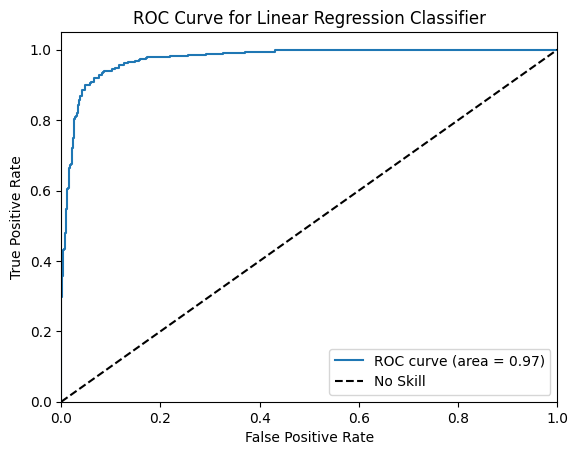

AUC: 0.9747337278106509


In [36]:
# Generate a graph that includes ROC curve for the logistic regression classifier on the testing set. 
# Compute the Area Under the Curve (AUC) metric. You can use a package for this.

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, lr_model.predict_proba(X_test)[:, 1]) 
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Linear Regression Classifier')
plt.legend()
plt.show()

print('AUC:', roc_auc)


Threshold: 0.0, TPR: 1.00, FPR: 1.00, AUC_so_far: 0.0000
Threshold: 0.1, TPR: 0.99, FPR: 0.31, AUC_so_far: 0.6879
Threshold: 0.2, TPR: 0.97, FPR: 0.15, AUC_so_far: 0.8398
Threshold: 0.3, TPR: 0.94, FPR: 0.09, AUC_so_far: 0.8977
Threshold: 0.4, TPR: 0.91, FPR: 0.06, AUC_so_far: 0.9236
Threshold: 0.5, TPR: 0.87, FPR: 0.04, AUC_so_far: 0.9460
Threshold: 0.6, TPR: 0.83, FPR: 0.03, AUC_so_far: 0.9498
Threshold: 0.7, TPR: 0.79, FPR: 0.03, AUC_so_far: 0.9557
Threshold: 0.8, TPR: 0.72, FPR: 0.02, AUC_so_far: 0.9591
Threshold: 0.9, TPR: 0.60, FPR: 0.01, AUC_so_far: 0.9659
Threshold: 1.0, TPR: 0.00, FPR: 0.00, AUC_so_far: 0.9695
Manual AUC: 0.969458112737465


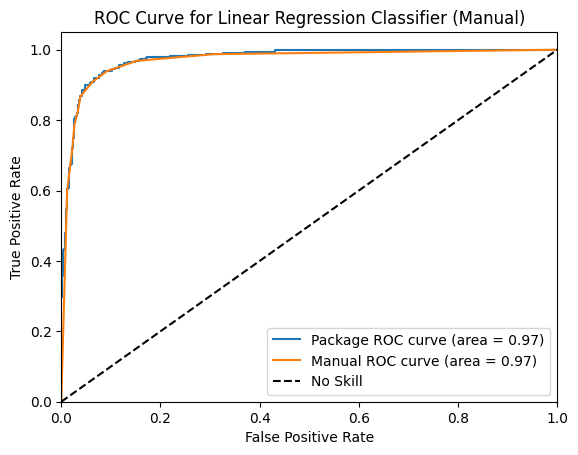


Observations:
The two ROC curves are extremely similar, with almost identical AUCs. The manual implementation was slightly lower, 0.969 as 
opposed to 0.974, but extremely close. The package graph was also slightly smoother than the manually generated one, due to it having more 
points from considering more thresholds. In order to make the manual graph more similar to the package, we would 
have to increase the number of threshold iterations to increase the number of points.


In [37]:
# Write code to plot a ROC curve without a package for logistic regression. Vary the prediction threshold $T \in 
# \{0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1\}$, and compute false positive and true positive rates for each threshold. 
# Plot a ROC curve for these points, and compare it with the ROC curve generated with the package in part (3). 
# What are the differences and what changes can you make to get the two ROC curves to become more similar?

thresholds = np.arange(0, 1.1, 0.1)
tpr_list = []
fpr_list = []
for t in thresholds:
    predictions_threshold = (model.predict_proba(X_test)[:, 1] >= t).astype(int)
    
    tp = np.sum((predictions_threshold == 1) & (y_test == 1))
    fp = np.sum((predictions_threshold == 1) & (y_test == 0))
    tn = np.sum((predictions_threshold == 0) & (y_test == 0))
    fn = np.sum((predictions_threshold == 0) & (y_test == 1))
    
    man_tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    man_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    tpr_list.append(man_tpr)
    fpr_list.append(man_fpr)

    order = np.argsort(fpr_list)  # ensure x-axis is increasing
    auc = np.trapz(np.array(tpr_list)[order], np.array(fpr_list)[order])

    print(f'Threshold: {t:.1f}, TPR: {man_tpr:.2f}, FPR: {man_fpr:.2f}, AUC_so_far: {auc:.4f}')

print('Manual AUC:', auc)

plt.figure()
plt.plot(fpr, tpr, label='Package ROC curve (area = %0.2f)' % roc_auc)
plt.plot(fpr_list, tpr_list, label='Manual ROC curve (area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for Linear Regression Classifier (Manual)')
plt.legend()
plt.show()

print('\nObservations:')
print('The two ROC curves are extremely similar, with almost identical AUCs. The manual implementation was slightly lower, 0.969 as \nopposed to 0.974, but extremely close. The package graph was also slightly smoother than the manually generated one, due to it having more \npoints from considering more thresholds. In order to make the manual graph more similar to the package, we would \nhave to increase the number of threshold iterations to increase the number of points.')

# *[C]* Problem 4: Cross validation (25 points)

In this problem, you will implement your own $k$-fold cross-validation algorithm and apply it to two linear classifiers (Logistic Regression
and LDA). Use the *SPAMBASE* dataset for this problem.

1. Implement $k$-fold cross-validation (CV) for training a model. The CV algorithm consists of the following steps:
    1. Divide the entire data into $k$ partitions of equal size.
    2. Run $k$ experiments. In each experiment $i \in \{1,\dots,k\}$, train on $k-1$ partitions and test on the validation set
    (partition $i$).
    3. Record the validation error for each experiment.
    4. Compute and print the **average validation error** across all $k$ experiments.
2. Run the CV experiment for logistic regression and LDA for $k \in \{5,10\}$. You can use a package for training the logistic
regression and LDA models. Print for each model the average validation error for each value of $k$.
3. Which model performs better? Compare the results.

In [47]:
import warnings # ignore the future warning thrown by np.array_split because it calls Series.swapaxes, which is now deprecated 
# (but works for right now, would find a different solution if this was a long-standing piece of code)
warnings.filterwarnings("ignore", message=".*swapaxes.*deprecated.*")

def manual_cv(k, X, y, model):
    
    # Shuffle the data
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    X_shuffled = X.iloc[indices] if isinstance(X, pd.DataFrame) else X[indices]
    y_shuffled = y.iloc[indices] if hasattr(y, 'iloc') else y[indices]

    X_folds = np.array_split(X_shuffled, k)
    y_folds = np.array_split(y_shuffled, k)

    val_scores = []
    for i in range(k):
        # split to make one fold the validation set and the rest the training set
        X_val = X_folds[i]
        y_val = y_folds[i]
        X_train_mancv = pd.concat([fold for j, fold in enumerate(X_folds) if j != i]) if isinstance(X, pd.DataFrame) else np.concatenate([fold for j, fold in enumerate(X_folds) if j != i])
        y_train_mancv = pd.concat([fold for j, fold in enumerate(y_folds) if j != i]) if hasattr(y, 'iloc') else np.concatenate([fold for j, fold in enumerate(y_folds) if j != i])

        # fit the model on the training set and evaluate on the validation set
        model.fit(X_train_mancv, y_train_mancv)
        mancv_pred = model.predict(X_val) 
        val_error = accuracy_score(mancv_pred, y_val)
        val_scores.append(val_error)

    print(f"Average validation error across {k} folds: {np.mean(val_scores):.4f}")
    return np.mean(val_scores)

In [48]:
for k in range(5, 11):
    print('\n Logistic regression model:')
    manual_cv(k, X_train, y_train, lr_model)
    print('\n LDA model:')
    manual_cv(k, X_train, y_train, lda_model)


 Logistic regression model:
Average validation error across 5 folds: 0.9194

 LDA model:
Average validation error across 5 folds: 0.8858

 Logistic regression model:
Average validation error across 6 folds: 0.9183

 LDA model:
Average validation error across 6 folds: 0.8858

 Logistic regression model:
Average validation error across 7 folds: 0.9191

 LDA model:
Average validation error across 7 folds: 0.8826

 Logistic regression model:
Average validation error across 8 folds: 0.9183

 LDA model:
Average validation error across 8 folds: 0.8843

 Logistic regression model:
Average validation error across 9 folds: 0.9215

 LDA model:
Average validation error across 9 folds: 0.8829

 Logistic regression model:
Average validation error across 10 folds: 0.9226

 LDA model:
Average validation error across 10 folds: 0.8858
